In [6]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import cross_val_score


In [2]:

df = pd.read_csv(r"C:\Users\shard\OneDrive\Desktop\TOPS\ML\Supervised\Assignment_Assesment\Pharmaceutical_Supply_Chain_Optimization.csv")


In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB


,Demand_Forecast,Optimal_Stock_Level
count,100000.000000,100000.000000
mean,5489.372180,6270.155320
std,2597.544993,2744.393068
min,1000.000000,1500.000000
25%,3243.000000,3899.750000
50%,5487.000000,6278.000000
75%,7738.000000,8660.000000
max,9999.000000,10999.000000


In [4]:
df.isnull().sum()

# Fill numeric
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical
df.fillna(df.mode().iloc[0], inplace=True)

In [5]:
numeric_df = df.select_dtypes(include=['number'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

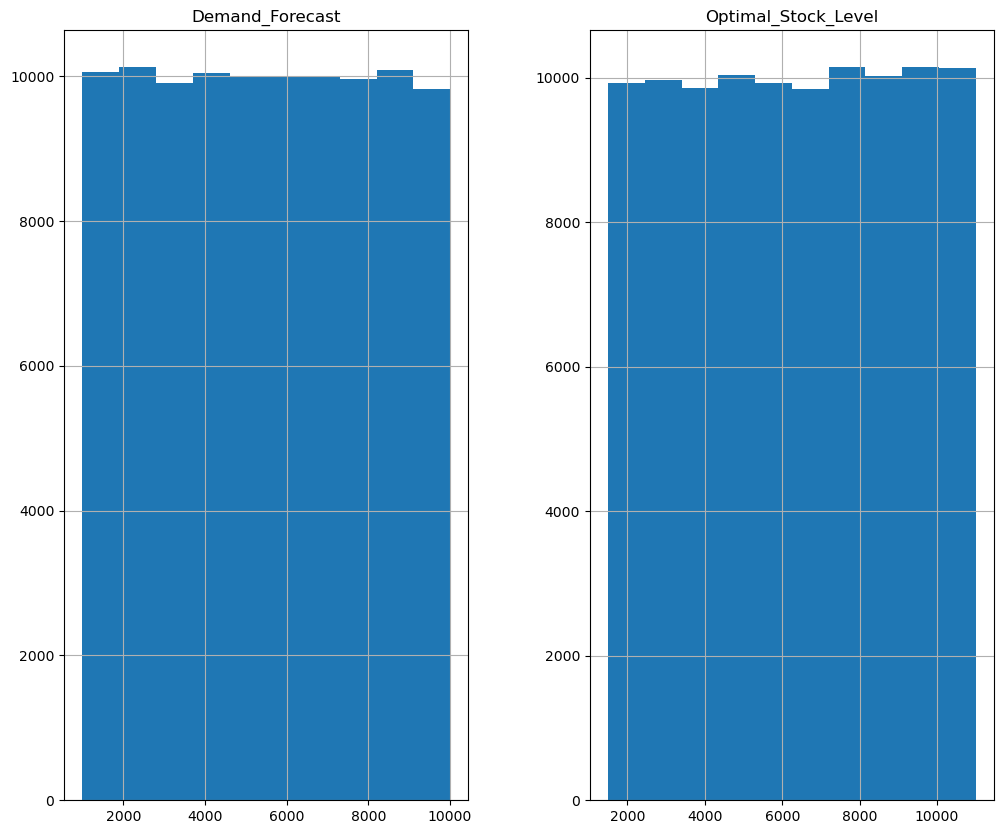

In [8]:
# 3 EDA
df.hist(figsize=(12,10))
plt.show()

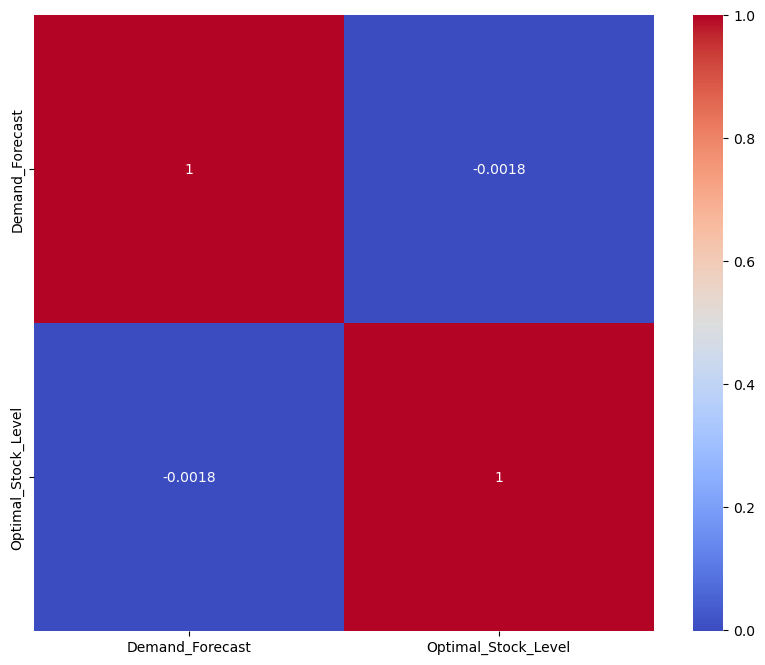

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [10]:
print(df.columns.tolist())

['Drug', 'Demand_Forecast', 'Optimal_Stock_Level', 'Restocking_Strategy']


In [11]:
# 4. Feature Engineering

df['demand_stock_ratio'] = df['Demand_Forecast'] / df['Optimal_Stock_Level']
df['stock_gap'] = df['Optimal_Stock_Level'] - df['Demand_Forecast']
df['high_demand'] = (df['Demand_Forecast'] > df['Demand_Forecast'].mean()).astype(int)

In [12]:
df['Restocking_Strategy'].value_counts()

Restocking_Strategy
Quarterly    33523
Weekly       33439
Monthly      33038
Name: count, dtype: int64

In [13]:
# 5. Encode Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [14]:
# 6. Build Linear Regression Model

X = df.drop(['Optimal_Stock_Level'], axis=1)
y = df['Optimal_Stock_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [15]:
# 7. Random Forest Regressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [16]:
# 8. Gradient Boosting Model
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

GradientBoostingRegressor()

In [17]:
# 9. Perform hyperparameter tuning using GridSearchCV.

param_dist = {
    'n_estimators': [20, 50], 
    'max_depth': [5, 10]        
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=2,       
    cv=2,           
    n_jobs=1,       
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best Params:", search.best_params_)

Best Params: {'n_estimators': 50, 'max_depth': 10}


In [ ]:
# 10. Evaluate Final Model

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 50.08034501314505


In [19]:
scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-scores)

print("CV RMSE:", rmse_cv.mean())

CV RMSE: 51.974290582831216
